# gmanifold on SimpleStories-11M — from cloning to use

This notebook clones the `gmanifold` repository, installs it, runs its test suite, and then applies the sampler to a
checkpoint it was not developed on: **SimpleStories/SimpleStories-11M** (Llama architecture, 6 blocks, D = 384,
4096-token vocabulary; the collection has 1.25M/5M/11M/30M/35M models, `MODEL` below selects one). Steps: define the
real embedding cloud (tokens that actually occur in the SimpleStories stories),
fit `GlobalManifold`, sample at several α, validate with the kernel score and tangent charts against calibration
bands, push samples through the real model to independently fitted destination manifolds, and look at what the
model predicts for the samples.

In [1]:
import os, subprocess, sys, time, json
WORK = os.path.abspath(".")                              # this notebook's folder
REPO = os.path.join(WORK, "gmanifold_repo")           # not "gmanifold": that name would shadow the package
token = os.environ.get("GH_TOKEN", "")                   # only needed while the repository is private
url = f"https://{token + '@' if token else ''}github.com/JVrabel/gmanifold.git"
if not os.path.exists(REPO):
    subprocess.run(["git", "clone", "-q", url, REPO], check=True)
print("repo at", REPO, "| commit", subprocess.run(["git", "-C", REPO, "log", "--oneline", "-1"], capture_output=True, text=True).stdout.strip())
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", REPO], check=True)
sys.path.insert(0, REPO)                                 # the running kernel started before the install; make the package importable now
print("installed")

repo at /workspace/projects/gmanifold_test/gmanifold_repo | commit cc3532f Transformer helpers: support GPT-2/GPT-Neo-style models (transformer.h, ln_2); test on TinyStories-8M


installed


In [2]:
# the test suite: synthetic-sheet exactness of the volume-uniform sampler, validators, filters, and hook exactness on two model families
r = subprocess.run([sys.executable, "-m", "pytest", os.path.join(REPO, "tests"), "-q"], capture_output=True, text=True)
print(r.stdout[-600:])

m......                                                         [100%]
=============================== warnings summary ===============================
tests/test_manifold.py: 18 warnings
  /venv/main/lib/python3.12/site-packages/torch/jit/_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
    warnings.warn(

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
16 passed, 18 warnings in 56.28s



In [3]:
import torch, gmanifold as gm
from gmanifold import transformer as tr
from transformers import AutoModelForCausalLM, AutoTokenizer
torch.manual_seed(0)
MODEL = "SimpleStories/SimpleStories-11M"
name = MODEL
model = AutoModelForCausalLM.from_pretrained(name, dtype=torch.float32).cuda().eval()
for p in model.parameters():
    p.requires_grad_(False)
tok = AutoTokenizer.from_pretrained(name)
print(type(model).__name__, sum(p.numel() for p in model.parameters()) / 1e6, "M params | locations:", tr.locations(model))

model.safetensors: reconstructing file:   0%|          |  0.00B / 44.1MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/56 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/591 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/88.1k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

LlamaForCausalLM 11.01504 M params | locations: ['embed', 'L0.attn', 'L0.ffn', 'L1.attn', 'L1.ffn', 'L2.attn', 'L2.ffn', 'L3.attn', 'L3.ffn', 'L4.attn', 'L4.ffn', 'L5.attn', 'L5.ffn']


## 1. The real embedding cloud

Not every vocabulary row is a real state: tokens that never occur in the training text keep an untrained
embedding (SimpleStories has ~150 such symbol tokens sitting on top of each other). We define the cloud as the
embedding rows of tokens that occur at least 5 times in the first 20k SimpleStories stories, then apply the
library's two filters (near-duplicate rows, isolated rows).

In [4]:
from collections import Counter
from datasets import load_dataset
counts = Counter()
for i, ex in enumerate(load_dataset("SimpleStories/SimpleStories", split="train", streaming=True)):
    counts.update(tok(ex["story"], add_special_tokens=False)["input_ids"])
    if i >= 20000:
        break
X_all, ids_all = tr.vocab_states(model, tok)
keep_ids = [v for v in ids_all if counts[v] >= 5]
X_emb = tr._arch(model)[0].weight[keep_ids].detach()          # embedding rows (architecture-agnostic)
clean = ~gm.degenerate_mask(X_emb) & ~gm.outlier_mask(X_emb)
X_emb, ids = X_emb[clean], [v for v, k in zip(keep_ids, clean.tolist()) if k]
print(f"tokens seen >=5 times: {len(keep_ids)} of {len(ids_all)}; after filters: {len(ids)} (dropped {int((~clean).sum())})")
print("intrinsic dimension:", {k: round(v, 2) for k, v in gm.intrinsic_dimension(X_emb).items()})
print("examples:", [tok.decode([v]) for v in ids[:12]])

tokens seen >=5 times: 3781 of 4094; after filters: 3781 (dropped 0)
intrinsic dimension: {'twonn': 19.61, 'mle': 29.55, 'spacing_median': 0.83}
examples: ['!', '"', "'", ',', '-', '.', '0', '1', '2', '3', '5', '6']


## 2. Fit the embedding manifold and sample

90 % of the tokens fit the model, 10 % are held out for calibration. Every distance below is in units of the local
spacing (distance to the 8-th real neighbour). Bands: held-out real states, and real states displaced by 0.5× / 1×
their spacing.

In [5]:
perm = torch.randperm(len(ids), generator=torch.Generator().manual_seed(0)); n_val = len(ids) // 10
tr_i, va_i = perm[:-n_val], perm[-n_val:]
Xtr, Xva = X_emb[tr_i], X_emb[va_i]
t0 = time.time()
M_in = gm.GlobalManifold(latent_dim=16).fit(Xtr, epochs=300, X_val=Xva, seed=0)
print(f"fit in {time.time() - t0:.0f}s | held-out recon / spacing {M_in.history[-1]['val_recon_over_spacing']:.3f} | Jacobian rank {M_in.jacobian_rank()['rank_median']:.0f} | spacing unit: {M_in.spacing_unit} (hub share {M_in.hub_share:.2f})")
kernel, charts = gm.KernelScore(Xtr), gm.TangentCharts(Xtr, 16)
bands = {k: v for k, v in gm.support_report(M_in, Xva, Xva, kernel, charts).items() if k != "samples"}
rows = {}
for alpha in (0.1, 0.3, 0.5, 0.7, 1.0, 1.5):
    x, info = M_in.sample(2000, alpha=alpha, seed=0)
    rows[f"samples α={alpha}"] = dict(**gm.support_report(M_in, x, kernel=kernel, tangent=charts)["samples"], coverage=M_in.coverage(x), ess=info["ess"])
rows.update({f"band: {k}": v for k, v in bands.items()})
import pandas as pd
pd.DataFrame(rows).T.round(3)

fit in 4s | held-out recon / spacing 0.812 | Jacobian rank 16 | spacing unit: anchor (hub share 0.14)


,nearest_real,recon,u,tangent,coverage,ess
samples α=0.1,0.634,0.137,1.199,0.600,1.000,1405.596
samples α=0.3,0.654,0.160,1.189,0.617,0.998,1413.490
samples α=0.5,0.689,0.206,1.162,0.646,1.000,1417.232
samples α=0.7,0.752,0.286,1.121,0.697,1.000,1430.562
samples α=1.0,0.880,0.474,1.024,0.801,0.996,1404.835
samples α=1.5,1.169,1.035,0.772,1.046,0.100,1008.407
band: held-out real,0.961,0.812,0.992,0.892,NaN,NaN
band: real + 0.5x noise,1.073,0.967,0.910,1.023,NaN,NaN
band: real + 1x noise,1.379,1.343,0.694,1.331,NaN,NaN


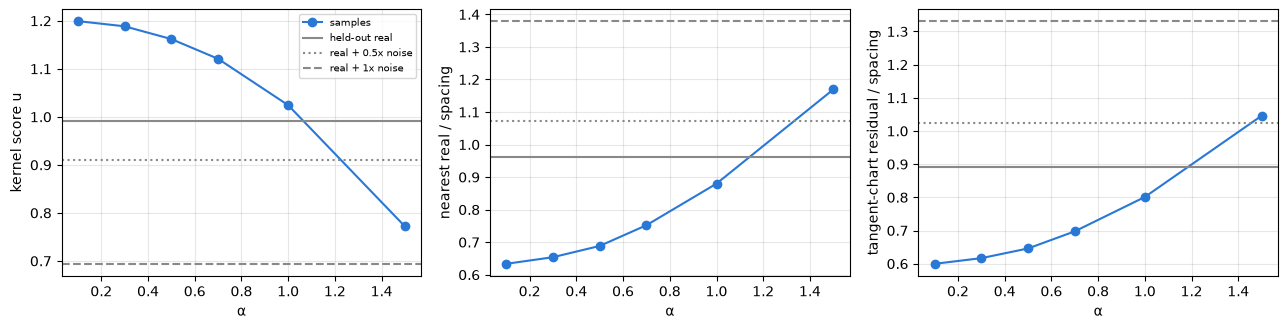

In [6]:
import matplotlib.pyplot as plt
alphas = [0.1, 0.3, 0.5, 0.7, 1.0, 1.5]
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
for k, (key, lab) in enumerate((("u", "kernel score u"), ("nearest_real", "nearest real / spacing"), ("tangent", "tangent-chart residual / spacing"))):
    ax[k].plot(alphas, [rows[f"samples α={a}"][key] for a in alphas], "-o", color="#2a78d6", label="samples")
    for b, ls in (("held-out real", "-"), ("real + 0.5x noise", ":"), ("real + 1x noise", "--")):
        ax[k].axhline(bands[b][key], ls=ls, color="#8a8985", label=b)
    ax[k].set_xlabel("α"); ax[k].set_ylabel(lab); ax[k].grid(alpha=0.3)
ax[0].legend(fontsize=7); fig.tight_layout(); plt.show()

## 3. Push samples through the real model and validate at the destination

Contextual states: the prefix *"Once upon a time, there was a little"* followed by each real token; the state at the
last position is recorded at every location. Destination manifolds are fitted **independently** on real destination
states (they never see the propagated samples). Controls: images of held-out real tokens, and of real tokens displaced
by one spacing *before* propagation.

In [7]:
prefix = tok("Once upon a time, there was a little", add_special_tokens=False)["input_ids"]; L = len(prefix)
seqs = torch.tensor([prefix + [v] for v in ids]); pos = torch.full((len(ids),), L)
dsts = ["L0.ffn", "L2.ffn", "L5.ffn"]
states = tr.collect_states(model, seqs, pos, dsts)
X_sample, info = M_in.sample(2000, alpha=0.3, seed=0)
g = torch.Generator(device="cuda").manual_seed(0)
j = gm.knn(Xtr, 1, Xva)[1][:, 0]; nz = torch.randn(Xva.shape, device="cuda", generator=g)
Xva_noise = Xva + nz / nz.norm(dim=1, keepdim=True) * M_in.spacing[j][:, None]
out = {}
for dst in dsts:
    Y = states[dst].cuda(); Ytr, Yva = Y[tr_i], Y[va_i]
    M_out = gm.GlobalManifold(latent_dim=16).fit(Ytr, epochs=300, X_val=Yva, seed=0)
    k_out, T_out = gm.KernelScore(Ytr), gm.TangentCharts(Ytr, 16)
    f = tr.make_map(model, "embed", dst, seqs[0], pos=L)
    rep = {f"{dst}: images of samples α=0.3": gm.support_report(M_out, f(X_sample), kernel=k_out, tangent=T_out)["samples"],
           f"{dst}: images of held-out real": gm.support_report(M_out, f(Xva), kernel=k_out, tangent=T_out)["samples"],
           f"{dst}: images of real + 1x noise": gm.support_report(M_out, f(Xva_noise), kernel=k_out, tangent=T_out)["samples"]}
    rep.update({f"{dst}: band {k}": v for k, v in gm.support_report(M_out, Yva, Yva, k_out, T_out).items() if k != "samples"})
    out.update(rep)
    print(f"{dst}: destination fit held-out recon {M_out.history[-1]['val_recon_over_spacing']:.3f}")
pd.DataFrame(out).T.round(3)

L0.ffn: destination fit held-out recon 0.747


L2.ffn: destination fit held-out recon 0.721


L5.ffn: destination fit held-out recon 0.701


,nearest_real,recon,u,tangent
L0.ffn: images of samples α=0.3,0.735,0.673,1.009,0.670
L0.ffn: images of held-out real,0.875,0.747,0.994,0.799
L0.ffn: images of real + 1x noise,1.151,0.997,0.894,1.096
L0.ffn: band held-out real,0.875,0.747,0.994,0.799
L0.ffn: band real + 0.5x noise,1.009,0.907,0.904,0.940
L0.ffn: band real + 1x noise,1.314,1.266,0.663,1.253
L2.ffn: images of samples α=0.3,0.762,0.670,0.995,0.672
L2.ffn: images of held-out real,0.847,0.721,0.997,0.753
L2.ffn: images of real + 1x noise,1.040,0.813,1.003,0.981
L2.ffn: band held-out real,0.847,0.721,0.997,0.753


## 4. What the model predicts for the samples

A sample replaces the embedding at the last position of the prefix and the full model is run. If samples are
meaningful interpolations, their next-token distribution should be close to their nearest real token's and far from a
random token's (Jensen–Shannon divergence), with sensible top predictions.

In [8]:
@torch.no_grad()
def next_token_logp(x):
    ctx = seqs[0].cuda(); out = []
    for xb in x.split(512):
        with tr._Hooks(model, [], {"embed": (xb, torch.full((len(xb),), L, device="cuda"))}):
            out.append(model(input_ids=ctx[None].expand(len(xb), -1)).logits[:, L].log_softmax(-1))
    return torch.cat(out)
def js(p, q):
    m = 0.5 * (p.exp() + q.exp()); return 0.5 * ((p.exp() * (p - m.log())).sum(-1) + (q.exp() * (q - m.log())).sum(-1))
lp_real = next_token_logp(Xtr)
res = {}
for label, x in (("held-out real tokens", Xva), ("samples α=0.3", X_sample), ("samples α=1.5", M_in.sample(2000, alpha=1.5, seed=0)[0]), ("real + 1x noise", Xva_noise)):
    lp = next_token_logp(x); j2 = gm.knn(Xtr, 2, x)[1]; rnd = torch.randint(len(Xtr), (len(x),), generator=torch.Generator().manual_seed(1)).cuda()
    res[label] = dict(js_nearest=float(js(lp, lp_real[j2[:, 0]]).median()), js_random=float(js(lp, lp_real[rnd]).median()),
                      top1_agrees_nearest=float((lp.argmax(-1) == lp_real[j2[:, 0]].argmax(-1)).float().mean()), entropy=float((-(lp.exp() * lp).sum(-1)).median()))
display(pd.DataFrame(res).T.round(3))
lp = next_token_logp(X_sample[:8]); j2 = gm.knn(Xtr, 2, X_sample[:8])[1]
for i in range(8):
    near = [tok.decode([ids[int(tr_i[j2[i, k]])]]) for k in range(2)]
    print(f"sample between {near[0]!r} and {near[1]!r}  ->  predicts {[tok.decode([int(t)]) for t in lp[i].topk(3).indices]}   (nearest token predicts {[tok.decode([int(t)]) for t in lp_real[j2[i, 0]].topk(3).indices]})")

,js_nearest,js_random,top1_agrees_nearest,entropy
held-out real tokens,0.451,0.605,0.246,2.262
samples α=0.3,0.175,0.536,0.378,2.774
samples α=1.5,0.269,0.507,0.301,2.541
real + 1x noise,0.482,0.541,0.151,3.226


sample between 'is' and 'was'  ->  predicts ['full', 'a', 'sad']   (nearest token predicts ['##le', '##ol', '##s'])
sample between 'tasty' and 'r'  ->  predicts ['boy', 'apple', 'girl']   (nearest token predicts ['carrot', 'food', 'cake'])
sample between 'r' and 'ed'  ->  predicts ['named', 'who', '.']   (nearest token predicts ['[EOS]', 'named', 'or'])
sample between 'luis' and 'emmanuel'  ->  predicts ['.', 'who', ',']   (nearest token predicts ['who', '.', ','])
sample between 'fears' and 'struggles'  ->  predicts ['.', 'in', ',']   (nearest token predicts ['##ome', '.', 'that'])
sample between 'himself' and 'herself'  ->  predicts ['.', ',', 'with']   (nearest token predicts ['.', 'with', ','])
sample between 'letter' and 'book'  ->  predicts ['that', '.', 'on']   (nearest token predicts ['.', 'from', 'that'])
sample between 'walked' and 'approached'  ->  predicts ['in', 'alone', '.']   (nearest token predicts ['in', 'alone', 'by'])


## 5. Pictures: real states (grey) and samples at two α, at the embedding and after block 2

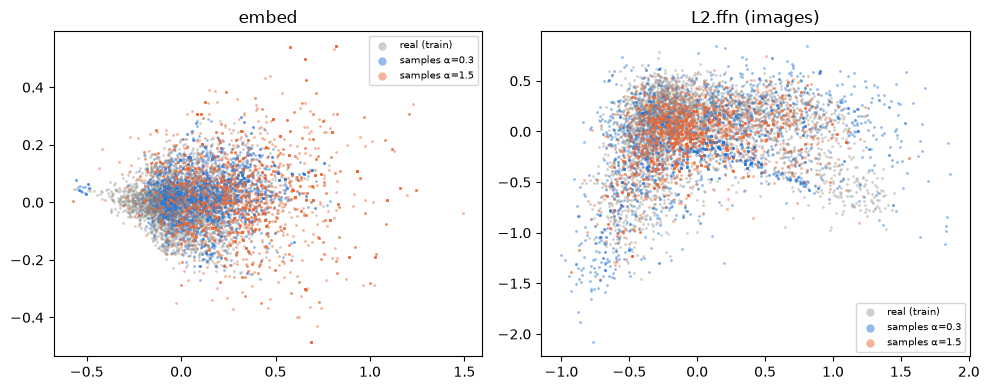

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
X3 = states["L2.ffn"].cuda(); f3 = tr.make_map(model, "embed", "L2.ffn", seqs[0], pos=L)
x15 = M_in.sample(2000, alpha=1.5, seed=0)[0]
for k, (ref, sets, title) in enumerate(((Xtr, {"samples α=0.3": X_sample, "samples α=1.5": x15}, "embed"), (X3[tr_i], {"samples α=0.3": f3(X_sample), "samples α=1.5": f3(x15)}, "L2.ffn (images)"))):
    mu = ref.mean(0); W = torch.linalg.svd(ref - mu, full_matrices=False)[2][:2].T; P = lambda Z: ((Z - mu) @ W).cpu()
    p = P(ref); ax[k].scatter(p[:, 0], p[:, 1], s=4, c="#8a8985", alpha=0.4, lw=0, label="real (train)")
    for (lab, Z), col in zip(sets.items(), ("#2a78d6", "#eb6834")):
        p = P(Z); ax[k].scatter(p[:, 0], p[:, 1], s=4, c=col, alpha=0.5, lw=0, label=lab)
    ax[k].set_title(title); ax[k].legend(fontsize=7, markerscale=3)
fig.tight_layout(); plt.show()

## 6. Reading the results

* Section 2: samples at small α should sit **above the held-out-real band** on the kernel score and **below it** on
  nearest-real distance and tangent residual, with coverage near 1; α = 1.5 should approach the one-spacing noise band.
* Section 3: images of the samples should be scored by the independent destination fits like images of real held-out
  tokens, and unlike images of noise-displaced tokens (at early blocks; deeper blocks heal mild displacements).
* Section 4: samples' next-token distributions should be closer to their nearest token's than to a random token's,
  with top-1 agreement well above the random baseline; noise should lose that relation.

Everything printed above is computed live; compare with the same tables for SimpleStories and TinyLlama in
`gmanifold/results/results.pdf`.